# GPT Model Training

## Background

In our last [computational essay](https://github.com/umairkhancis/llm-under-the-hood/blob/main/gpt_module/notebooks/gpt-model-essay.ipynb), we successfully invoked the `GPTModel` abstraction inside a simple application and generated one token as well as multiple tokens autoregressively.

However, the generated text was not coherent with the given prompt.

This is because the model was initialized with random weights and had not yet learned the statistical patterns of language usage from the training corpus.

And that is precisely the goal of this computational essay.

## Goal

Find the values of the neural network parameters of the `GPTModel` that enable it to generate coherent text for a given prompt.

This process of finding the optimal values of the neural network parameters—**weights** and **biases**—is called **training**.

Training consists of repeatition of learning steps: 
- In each step, the model first predicts an output and
- then compares it with the already known correct output, called the **target**.
- It then computes a score that measures the quality of its prediction.
- Based on this score, the model determines how much each weight and bias should be updated to improve the quality of future predictions.

By repeating this process over many training examples, the model gradually learns better parameter values, resulting in increasingly coherent text generation. 

Once the parameter values have been sufficiently optimized, the training objective is considered achieved.

## Recipe:
1. Quantify the quality of generated text using a loss function.
2. Prepare the datasets for training loop.
3. Prepare the training loop.
4. Execute model training to witness learning curve.
5. Save the model's optimal parameters values i.e learning progress.
6. Load the model's parameters values i.e trained model.

## Step 1: Quantify the quality of generated text using a loss function.

- Import the abstraction `GPTModel` built in the last [computational essay](https://github.com/umairkhancis/llm-under-the-hood/blob/main/gpt_module/notebooks/gpt-model-essay.ipynb).
- Write helper functions to generate next tokens from `GPTModel`.
- Write a function to quantify the quality of the tokens generated by `GPTModel`.
- Use pytorch built-in abstraction to represent the quality of the tokens generated by `GPTModel`.

### 1(a): Import the abstraction `GPTModel`

In [1]:
import torch
import torch.nn as nn

import tiktoken

# Import already prepared `GPTModel` abstraction
import sys 
sys.path.append("../..")

from gpt_module import GPTModel

torch.manual_seed(123)
context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
tokenized_context = tokenizer.encode(context)
input_sequence = torch.tensor(tokenized_context).unsqueeze(0)

GPT_CONFIG = {
    "vocab_size": 50257,          # Vocabulary size, the number of unique tokens available to be generated.
    "context_window_size": 256,   # Context window size, the maximum number of tokens model can see, learn and effectively predict on.
    "emb_dim": 768,               # Embedding dimension to capture meaning in a vector space.
    "n_heads": 12,                # Number of attention heads.
    "n_layers": 12,               # Number of transformer block layers. 
    "drop_rate": 0.1,             # Dropout rate to avoid overfitting.
    "qkv_bias": False             # Weather Query-Key-Value matrices includes bias along with weights.
}

### 1(b): Write helper functions to generate next tokens from `GPTModel`.

In [2]:
import tiktoken

def text_generation_app(model, input_text, max_new_tokens, context_window_size):
    
    for i in range(max_new_tokens):
        # Truncate input_text to the size limit of the context window.
        limited_context_window = input_text[:, -context_window_size:]

        # Disable computation graph of back propgation in background
        with torch.no_grad():
            logits = model(limited_context_window)

        # Extract the last index value
        logits = logits[:, -1, :]

        # Normalize for easier interpretation of logits scores as probabilities; it is optional as high scores in logits always leads to high probablities.
        probabilities = torch.softmax(logits, dim=-1)

        # Extract the index of the max value in probabilities as index represent the most likelable next_token_id which should come after the last token in the input_text.
        next_token_id = torch.argmax(probabilities, dim=-1, keepdim=True)

        # Concatenate next_token_id to the input_text.
        input_text = torch.cat((input_text, next_token_id), dim=1)

    # At the end of the loop (reaching limit of max tokens) autoregressiveness of input_text is the output_text.
    output_text = input_text
    
    return output_text


# Helper function to convert python list to tensors after invoking tokenizer to encode text into token_ids.
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

# Helper function to convert tensors back to python list and invoke tokenizer decode token_ids to text.
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

### 1(c): Write a Function to Quantify the Quality of the Tokens Generated by `GPTModel`

**Goal:**

> We want a single number that represents the quality of the next-token predictions generated by the model.

Before abstracting this process into a function, let us first understand it using a smaller example:

* Invoke the model to obtain the raw scores associated with every token in the vocabulary being the next token.
* Apply `softmax` to convert these raw scores into probabilities.
* Extract the probabilities assigned to the actual target tokens. The indices in the probability array correspond to token IDs.
* A high probability assigned to an actual target token indicates a high-quality prediction.
* However, probability values can be very small and do not penalize poor predictions as strongly as required.
* Use the mathematical function `-log(x)` to transform small probabilities into larger values, representing poor prediction quality i.e loss value.
* Finally, combine all the loss values of each position into a single loss value representing overall output prediction quality.


In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

# Model initialization.
model = GPTModel(cfg=GPT_CONFIG)

# Model invocation.
logits = model(inputs)
print(f"Model raw scores (logits): {logits}\n")

# Normalize to transform logits into probabilities
probas = torch.softmax(logits, dim=-1)
print(f"Probability of each token being the next token: {probas}\n")

# Extract actual target tokens probability values for 1st example.
target_probabs_1 = probas[0, [0,1,2], targets[0]]
print(f"Probability of target tokens being the next token in 1st example: {target_probabs_1}\n")

# Extract actual target tokens probability values for 2nd example.
target_probabs_2 = probas[1, [0,1,2], targets[1]]
print(f"Probability of target tokens being the next token in 2nd example: {target_probabs_2}\n")

# Combine probability values of both examples.
target_probabs = torch.cat((target_probabs_1, target_probabs_2))
print(f"Combining probability values of all target tokens: {target_probabs}\n")

# Calculate the `-log(x)` value of the probability values
log_probabs = -1 * torch.log(target_probabs)
print(f"Negative Log of probability values of target tokens: {log_probabs}\n")

# Represent all the probability based log values in a single value.
mean_log_probabs = torch.mean(log_probabs)
print(f"Loss: {mean_log_probabs}\n")

Model raw scores (logits): tensor([[[ 0.2789, -0.3353, -0.5054,  ...,  0.6408, -1.5024,  0.4851],
         [-0.2757, -0.6219, -0.9619,  ...,  0.5280, -1.0855,  0.0695],
         [ 0.6484, -0.3530,  0.3794,  ...,  0.6551,  0.1678, -0.1509]],

        [[ 0.0666,  0.3181, -0.2962,  ..., -0.3758,  0.1733, -0.5357],
         [-0.7587, -0.4058, -0.3514,  ...,  0.2739, -0.5553, -0.0178],
         [ 0.8548,  0.5596,  1.1474,  ..., -1.0000,  1.1116, -0.4193]]],
       grad_fn=<UnsafeViewBackward0>)

Probability of each token being the next token: tensor([[[2.2227e-05, 1.2026e-05, 1.0145e-05,  ..., 3.1920e-05,
          3.7434e-06, 2.7317e-05],
         [1.2791e-05, 9.0480e-06, 6.4402e-06,  ..., 2.8571e-05,
          5.6910e-06, 1.8065e-05],
         [3.2204e-05, 1.1830e-05, 2.4609e-05,  ..., 3.2422e-05,
          1.9916e-05, 1.4480e-05]],

        [[1.8105e-05, 2.3281e-05, 1.2595e-05,  ..., 1.1632e-05,
          2.0142e-05, 9.9129e-06],
         [7.8604e-06, 1.1187e-05, 1.1811e-05,  ..., 2.2075

### **Note:** 

_The smaller the probability values are the higher the negative log values become. The higher the loss value is the worse the output predicted by the model._ 

Therefore during training the goal would be reduce this loss value indicator to know whether training is going in the right direction and learning is happening.

### Abstract Ouput Quality Indicator (Loss Value Calculation).

In [4]:
def calculate_loss(logits, targets):
    probas = torch.softmax(logits, dim=-1)
    
    context_length = targets.shape[1]
    
    token_pos = [i for i in range(targets.shape[1])]

    target_probabs = []
    for i in range(targets.shape[0]):
        target_probabs.append(probas[i, token_pos, targets[i]])
    target_probabs = torch.stack(target_probabs)

    log_probabs = -1 * torch.log(target_probabs)
    mean_log_probabs = torch.mean(log_probabs)

    return mean_log_probabs

## Test the abstraction.
loss = calculate_loss(logits, targets)
loss

tensor(10.8436, grad_fn=<MeanBackward0>)

### 1(d): Pytorch Built-In Loss Value Abstraction. 

Let's use pytorch built-in abstraction called `torch.nn.functional.cross_entropy` instead of custom implementation for standardization reasons.

In [5]:
cross_entropy_loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), targets.flatten(0,1))
cross_entropy_loss

tensor(10.8436, grad_fn=<NllLossBackward0>)

**Note:** _The `cross_entropy_loss` value is the same as our custom implementation loss abstraction._ Also we had to flatten the logits and targets for both examples all tokens positions. 

## Step 2: Prepare the Datasets for the Training Loop

A common machine learning practice is to reserve a small portion of the dataset for **validation**. This validation set is never used to update the model's parameters; instead, it is used to evaluate how well the trained model generalizes and to detect underfitting or overfitting.

The remaining, larger portion of the dataset is used for training.

The dataset preparation process consists of the following steps:

* (a): Load the training corpus.
* (b): Split the corpus into **training** and **validation** sets according to a configured split ratio.
* (c): Prepare batches of training examples, where every example contains exactly `context_window_size` input tokens (along with their corresponding target tokens).
* (d): Prepare batches of validation examples, where every example contains exactly `context_window_size` input tokens (along with their corresponding target tokens).
* (e): Prepare a helper function for loss calculation per batch.
* (f): Prepare a helper function for loss calculation for the whole training dataset and validation dataset together.
* (g): Verify the data loaders shape.

In [6]:
# Import already prepared `create_dataloader_v1` abstraction in embeddings_module.
import sys 
sys.path.append("../..")
from data_loader_module import create_dataloader_v1

torch.manual_seed(123)

# 2(a): Load the data corpus.
with open("data/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

# 2(b): Split the corpus into training and validation datasets.
train_to_validation_ratio = 0.90
split_idx = int(train_to_validation_ratio * len(corpus))
train_data = corpus[:split_idx]
val_data = corpus[split_idx:]

# 2(c): Prepare batches of training examples.
train_loader = create_dataloader_v1(
    train_data,
    tokenizer,
    batch_size=2,
    context_window_size=GPT_CONFIG["context_window_size"],
    stride=GPT_CONFIG["context_window_size"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

# 2(d): Prepare batches of training examples.
val_loader = create_dataloader_v1(
    val_data,
    tokenizer,
    batch_size=2,
    context_window_size=GPT_CONFIG["context_window_size"],
    stride=GPT_CONFIG["context_window_size"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# 2(e): Prepare a helper function for loss calculation per batch.
def calc_loss_batch(input_batch, target_batch, model, device):
    # Transfer the input and target data batches to the configured GPU device.
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

# 2(f): Prepare a helper function for loss calculation for the whole training dataset and validation dataset together.
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

# 2(g): Verify the data loaders shape.
for x,y in train_loader:
    print(f"Inputs(X): {x.shape} --> Targets(y): {y.shape}")

Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])


**Note:** Unlike validation dataset loader, the params `drop_last=True` and `shuffle=True` in training dataset.

## Step 3: Prepare the training loop.

In [7]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Iterate multiple times over the entire training dataset.
    for epoch in range(num_epochs):
        # Prepare the model for training phase.
        model.train()

        # Iterate over the batches
        for input_batch, target_batch in train_loader:

            # Reset gradients from previous batch.
            optimizer.zero_grad()

            # Calculate loss for the current batch.
            loss = calc_loss_batch(input_batch, target_batch, model, device)

            # Update model weights based on the current loss value to minimize it.
            loss.backward()
            optimizer.step()

            # Display training and validation losses every.
            tokens_seen += input_batch.numel()
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                      f"Training Quality (Loss) {train_loss:.3f}, "
                      f"Validation Quality (Loss) {val_loss:.3f}\n"
                )

        generate_and_print_sample(model, tokenizer, device, start_context)
        
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = text_generation_app(
            model=model, input_text=encoded,
            max_new_tokens=50, context_window_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print("==============================================")
    print("Umair-GPT> {}".format(decoded_text.replace('\n', ' ')))
    print("==============================================\n")
    model.train()

## Step 4: Execute the training loop to witness learning curve.

* (a): Initialize the GPTModel.
* (b): Check the GPU device support.
* (c): Transfer the model to the same device where the data will be available.
* (d): Select the learning optimization mechanism like Gradient Descent or AdamW.
* (e): Epoch represents the number of times model would see the whole training dataset examples for learning.
* (f): Start the training loop.
* (g): Witness the learning curve.

Epoch 1 (Step 000000): Training Quality (Loss) 9.781, Validation Quality (Loss) 9.933

Epoch 1 (Step 000005): Training Quality (Loss) 8.111, Validation Quality (Loss) 8.339

Umair-GPT> Every effort moves you,,,,,,,,,,,,.                                     

Epoch 2 (Step 000010): Training Quality (Loss) 6.661, Validation Quality (Loss) 7.048

Epoch 2 (Step 000015): Training Quality (Loss) 5.961, Validation Quality (Loss) 6.616

Umair-GPT> Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,

Epoch 3 (Step 000020): Training Quality (Loss) 5.726, Validation Quality (Loss) 6.600

Epoch 3 (Step 000025): Training Quality (Loss) 5.201, Validation Quality (Loss) 6.348

Umair-GPT> Every effort moves you, and I had been.                                            

Epoch 4 (Step 000030): Training Quality (Loss) 4.417, Validation Quality (Loss) 6.278

Epoch 4 (Step 000035): Training Quality (Loss) 4.069,

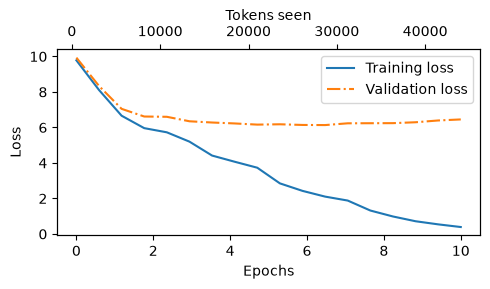

In [8]:
torch.manual_seed(123)

# 4(a): Initialize the GPTModel.
model = GPTModel(GPT_CONFIG)

# 4(b): Check the GPU device support.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4(c): Transfer the model to the same device where the data will be available.
model.to(device);

# 4(d): Select the learning optimization mechanism like Gradient Descent or AdamW.
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# 4(e): Epoch represents the number of times model would see the whole training dataset examples for learning.
num_epochs = 10

# 4(f): Start the training loop.
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# 4(g): Witness the learning curve.
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

**Note:** _Due to the very small size of corpus and then split into validation & training datasets, validation loss optimization saturated as compared to training loss optimization. For the very large corpus we will not likely be facing this problem._

## Step 5: Save the model's optimal parameters values i.e learning progress.

In [ ]:
torch.save(model.state_dict(), "model.pth")

## Step 6: Load the already trained model parameters values i.e learning progress.

* (a): Initialize the model with default weights (i.e. random weights).
* (b): Load the already saved parameters from the file.
* (c): Prepare model for inference.

In [ ]:
# 6(a): Initialize the model with default weights (i.e. random weights).
model = GPTModel(GPT_CONFIG)

# 6(b): Load the already saved parameters from the file.
model.load_state_dict(torch.load("model.pth", map_location=device))

# 6(c): Prepare model for inference phase.
model.eval();

## What Did We Learn?

In this computational essay, we reconstructed the complete **GPT model training pipeline** and transformed our randomly initialized GPT model into one that learns from data.

We learned:

* How to quantify the quality of the model's next-token predictions using a **loss function**.
* Why **Cross Entropy Loss** serves as an objective indicator of prediction quality during training.
* How to prepare a corpus by splitting it into **training** and **validation** datasets.
* How to organize the corpus into batches of input-target token sequences suitable for training.
* How the training loop repeatedly predicts, measures loss, computes gradients, and updates the model's weights using an optimization algorithm.
* How to monitor learning progress by comparing training and validation loss throughout training.
* How to visualize the learning curve to verify that the model is learning.
* How to save the learned model parameters and later reload them for inference without retraining.

At this point, we have completed the entire lifecycle of building a GPT model from first principles—from representing language as embeddings, constructing the Transformer architecture, assembling the GPT model, implementing autoregressive text generation, and finally training the model to learn the statistical patterns of language.

The remaining computational essays will build upon this trained GPT model by introducing text sampling and decoding techniques that improve the quality, efficiency, and capabilities of modern Large Language Models (LLMs).
